# 🧠 NeuroDSL – Stirling Numbers & Bell Numbers

This notebook demonstrates **NeuroDSL**, a Julia DSL for declarative,
recursive computation graphs with **automatic memoisation**.

We compute **Stirling numbers of the second kind** and the **Bell number** $ B_6 $,
then visualise the entire computation graph interactively.

---

## 📐 Recurrence

Stirling numbers of the second kind $ S(n,k) $ satisfy:

$$
S(n,k) =
\begin{cases}
1 & \text{if } n = 0,\; k = 0,\$$4pt]
0 & \text{if } k = 0 \text{ or } k > n,\$$4pt]
k \cdot S(n-1,k) + S(n-1,k-1) & \text{otherwise}.
\end{cases}
$$

The **Bell number**  $\displaystyle B_n = \sum_{k=1}^{n} S(n,k) $ counts all partitions of an $ n$-element set.

For $ n = 6 $, $ B_6 = 203 $.

---


# Installation (run once)

In [ ]:
using NeuroDSL, Printf

# Define custom operators with @defop

In [ ]:

@defop scale_add out = attrs[:factor] * inputs[1] + inputs[2]
@defop identity  out = inputs[1]
@defop nsum (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
    copyto!(out, inputs[1])
    for i in 2:length(inputs)
        out .+= inputs[i]
    end
end

# Build the recursive Stirling graph

In [ ]:
function build_stirling_graph(g, n)
    builder = @neuro g ns=:stirling operators=[:scale_add] begin
        @node one  = 1.0
        @node zero = 0.0

        @rule stirling(n::Int, k::Int) = begin
            if n == 0 && k == 0
                :one
            elseif k == 0 || k > n
                :zero
            else
                scale_add(factor=k, stirling(n-1, k), stirling(n-1, k-1))
            end
        end

        # Compute all S(n,k) for k=1..n
        all_terms = [stirling(n, i) for i in 1:n]
        @node bell = nsum(all_terms...)
    end
    return builder
end

n = 6
g = NeuroGraph(namespace=:stirling, device=Backend.CPUDevice())
builder = build_stirling_graph(g, n)

# Execute forward pass

In [ ]:
log = ExecutionLog()
ctx = CtxStore()
NeuroDSL.demand!(g, :bell; ctx_store=ctx, namespace=:stirling, log=log)

bell_val = Array(NeuroDSL.node(g, :bell; namespace=:stirling).value)[]
@printf "Bell number B_%d = %d\n" n Int(bell_val)

 # Generate interactive HTML trace

In [ ]:
save_interactive_graph(g, log, "stirling_bell_6.html";
                       title = "Stirling & Bell numbers (n=$n)")

In [ ]:
# Windows
run(`cmd /c start stirling_bell_6.html`)



# 🧩 Eulerian Numbers – A Complex Recurrence for NeuroDSL

Voici un exemple **complexe et élégant** qui mettra en valeur toute la puissance de NeuroDSL : les **nombres eulériens** $ A(n,k) $.  
Ils satisfont une récurrence double avec des coefficients **dépendants des deux variables** :

$$
A(n,k) = (n-k+1) \cdot A(n-1,k-1) + k \cdot A(n-1,k)
$$

avec les cas de base :
- $ A(0,0) = 1 $
- $ A(n,0) = 0 $ pour $ n > 0 $
- $ A(0,k) = 0 $ pour $ k > 0 $
- $ A(n,k) = 0 $ si $ k > n $

Leur somme pour un $ n $ donné donne $ n! $, ce qui fournit une vérification élégante.

---

### ⚙️ Pourquoi c’est parfait pour NeuroDSL

- **Deux coefficients différents** $ (n-k+1) $ et $ k $ qui varient avec $ n $ et $ k $.
- On peut utiliser un seul opérateur personnalisé `linear2` défini avec `@defop`.
- La récurrence est dense, le graphe sera riche et visuellement impressionnant.
- La mémoïsation est cruciale : chaque couple $ (n,k) $ n’est calculé qu’une fois.
- La somme finale permet de vérifier $ \sum_k A(n,k) = n! $.

---






In [ ]:
using NeuroDSL, Printf

# ── Opérateur personnalisé : combinaison linéaire à deux poids ──
@defop linear2 (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
    w1 = attrs[:w1]
    w2 = attrs[:w2]
    @. out = w1 * inputs[1] + w2 * inputs[2]
end

# Opérateurs de base
@defop nsum (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
    copyto!(out, inputs[1])
    for i in 2:length(inputs)
        out .+= inputs[i]
    end
end

@defop identity out = inputs[1]

# ── Construction du graphe ──────────────────────────────────
function build_eulerian_graph(g, n)
    builder = @neuro g ns=:euler operators=[:linear2] begin
        @node one  = 1.0
        @node zero = 0.0

        @rule eulerian(n::Int, k::Int) = begin
            if n == 0 && k == 0
                :one
            elseif k == 0 || k > n
                :zero
            else
                linear2(w1 = n - k + 1, w2 = k,
                        eulerian(n-1, k-1), eulerian(n-1, k))
            end
        end

        # Somme de tous les A(n,k) pour k=1..n
        all_terms = [eulerian(n, i) for i in 1:n]
        @node sum_euler = nsum(all_terms...)
    end
    return builder
end

# ── Exécution ───────────────────────────────────────────────
n = 5   # A(5,k) et somme = 5! = 120
g = NeuroGraph(namespace=:euler, device=Backend.CPUDevice())
builder = build_eulerian_graph(g, n)

log = ExecutionLog()
ctx = CtxStore()
NeuroDSL.demand!(g, :sum_euler; ctx_store=ctx, namespace=:euler, log=log)

sum_val = Array(NeuroDSL.node(g, :sum_euler; namespace=:euler).value)[]
println("Sum of Eulerian numbers A($n,k) = ", sum_val)
println("Expected n! = ", factorial(n))

# ── Visualisation interactive ───────────────────────────────
save_interactive_graph(g, log, "eulerian_n5.html";
                       title = "Eulerian numbers A($n,k) with NeuroDSL")

# MLP 

Train : 150 pts  |  Test : 50 pts
  classe 1 train = 75.0  classe 2 train = 75.0
  classe 1 test  = 25.0   classe 2 test  = 25.0
Epoch    1  loss = 0.3634  lr = 0.00999
Epoch  200  loss = 0.0983  lr = 0.00833
Epoch  400  loss = 0.0948  lr = 0.00714
Epoch  600  loss = 0.0921  lr = 0.00625
Epoch  800  loss = 0.0898  lr = 0.00556
Epoch 1000  loss = 0.0930  lr = 0.00500
Epoch 1200  loss = 0.0910  lr = 0.00455
Epoch 1400  loss = 0.0909  lr = 0.00417
Epoch 1600  loss = 0.0886  lr = 0.00385
Epoch 1800  loss = 0.0918  lr = 0.00357
Epoch 2000  loss = 0.0909  lr = 0.00333

TP = 20, TN = 24, FP = 1, FN = 5
Test accuracy = 88.0%


┌ Warning: Skipped marker arg triangle.
└ @ Plots C:\Users\Nevermind\.julia\packages\Plots\GIume\src\args.jl:1155


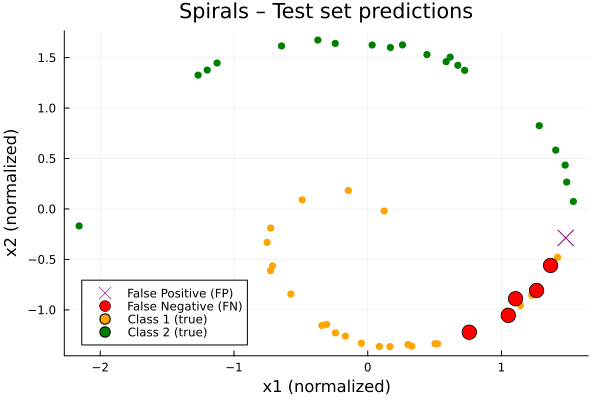

✅ Viewer animé exporté → spirals_sgd_training.html  (40 snapshots)
✅ Animation sauvegardée → spirals_sgd_training.html


NeuroGraph(Dict{Symbol, Dict{Symbol, GraphNode{Float32}}}(:spirals => Dict(:fc1_out => GraphNode{Float32}(:fc1_out, Float32[-0.24425094 -0.5432537 … 0.41021484 0.57284147; 0.011849135 -0.8294648 … 0.24188548 0.088311136; … ; -1.2913638 -0.4749527 … 1.718159 1.0048198; 0.7347026 -0.6121576 … -0.8097523 0.16188422], nothing, false, false, Quantom, false, :spirals, Dict{Symbol, Any}(:_inputs_buf => AbstractArray{Float32}[[-0.14492135 0.18256679; -0.7259423 -0.18915774; … ; 1.0508121 -1.0546978; -1.2682272 1.3266621], [-0.60694975 0.25973654; 0.32621714 0.2600638; … ; 0.5969457 -0.4802175; 0.6533395 0.28226918], [-0.37963018, -0.5434569, 0.55971766, -0.061165158, 0.5544049, 0.7004498, -0.37083477, -0.2602233, -0.48081484, 0.3644242  …  -0.38473463, -0.24251813, 0.05184837, -0.47149402, -0.4568801, 0.66060334, 0.097712144, 0.706705, 0.5843968, 0.61599135]]), Symbol[], nothing), :loss => GraphNode{Float32}(:loss, Float32[0.0932771], nothing, false, false, Quantom, false, :spirals, Dict{Symbo

In [21]:
using NeuroDSL, Printf, Random, LinearAlgebra, Statistics, Plots

# ═══════════════════════════════════════════════════════════════════════
# 1. Enregistrement fiable de :relu
# ═══════════════════════════════════════════════════════════════════════
if !haskey(NeuroDSL.CUSTOM_OPS, :relu)
    NeuroDSL.register_op!(:relu,
        (dev, out, inputs, attrs, out_sym, nd, ctx) -> begin
            x = inputs[1]
            out .= max.(x, 0f0)
            if ctx !== nothing
                ctx[out_sym] = Dict{Symbol,Any}(:x => x)
            end
        end
    )
    NeuroDSL.GRAD_RULES[:relu] = (dev, grad_out, ctx, inputs) -> begin
        x = inputs[1]
        [grad_out .* Float32.(x .> 0f0)]
    end
    println("✅ Opérateur :relu enregistré (manuel)")
end

# ═══════════════════════════════════════════════════════════════════════
# 2. Génération du dataset "Two Spirals"
# ═══════════════════════════════════════════════════════════════════════
function make_spirals(n_points::Int=200, noise::Float32=0.1f0)
    Random.seed!(42)
    n = n_points ÷ 2
    theta  = sqrt.(rand(Float32, n)) * 2f0 * Float32(π)
    r      = theta
    x0 = r .* cos.(theta) .+ noise .* randn(Float32, n)
    y0 = r .* sin.(theta) .+ noise .* randn(Float32, n)
    theta1 = sqrt.(rand(Float32, n)) * 2f0 * Float32(π) .+ Float32(π)
    r1     = theta1
    x1 = r1 .* cos.(theta1) .+ noise .* randn(Float32, n)
    y1 = r1 .* sin.(theta1) .+ noise .* randn(Float32, n)
    X = hcat(vcat(x0, x1), vcat(y0, y1))
    Y = vcat(zeros(Float32, n), ones(Float32, n))
    Y_onehot = zeros(Float32, length(Y), 2)
    for i in 1:length(Y)
        Y_onehot[i, Int(Y[i])+1] = 1f0
    end
    return X, Y_onehot
end

X_all, Y_all = make_spirals(200)

# ═══════════════════════════════════════════════════════════════════════
# FIX 3 — Split stratifié 75/25 par classe
#   Original : X_all[1:150,:] prenait 100 pts classe 1 + 50 pts classe 2,
#   et X_all[151:200,:] était UNIQUEMENT de la classe 2 → accuracy fictive.
# ═══════════════════════════════════════════════════════════════════════
Random.seed!(0)
n_per_class   = size(X_all, 1) ÷ 2          # 100 par spirale
perm_c1       = randperm(n_per_class)
perm_c2       = n_per_class .+ randperm(n_per_class)
n_train_each  = round(Int, 0.75 * n_per_class)   # 75 par classe

train_idx = vcat(perm_c1[1:n_train_each],        perm_c2[1:n_train_each])
test_idx  = vcat(perm_c1[n_train_each+1:end],    perm_c2[n_train_each+1:end])

X_train, Y_train = X_all[train_idx, :], Y_all[train_idx, :]
X_test,  Y_test  = X_all[test_idx,  :], Y_all[test_idx,  :]
println("Train : $(size(X_train,1)) pts  |  Test : $(size(X_test,1)) pts")
println("  classe 1 train = $(sum(Y_train[:,1]))  classe 2 train = $(sum(Y_train[:,2]))")
println("  classe 1 test  = $(sum(Y_test[:,1]))   classe 2 test  = $(sum(Y_test[:,2]))")

# ═══════════════════════════════════════════════════════════════════════
# 3. Normalisation robuste
# ═══════════════════════════════════════════════════════════════════════
mean_train = mean(X_train, dims=1)
std_train  = std(X_train,  dims=1) .+ 1f-8
X_train_norm = (X_train .- mean_train) ./ std_train
X_test_norm  = (X_test  .- mean_train) ./ std_train

# ═══════════════════════════════════════════════════════════════════════
# 4. Construction du MLP (couche cachée 128 neurones, ReLU)
# ═══════════════════════════════════════════════════════════════════════
g  = NeuroGraph(namespace=:spirals, device=NeuroDSL.Backend.CPUDevice())
ns = :spirals

NeuroDSL.set!(g, :X, zeros(Float32, 32, 2))
NeuroDSL.set!(g, :Y, zeros(Float32, 32, 2); atom_type=NeuroDSL.Datom)

h   = NeuroDSL.Linear(2,   128)(g, :X,    :fc1;  namespace=ns)
NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:relu1, [h],        :relu;     namespace=ns))
out = NeuroDSL.Linear(128,   2)(g, :relu1, :fc2;  namespace=ns)
NeuroDSL.addrule!(g, NeuroDSL.GraphRule(:loss,  [out, :Y],  :mse_loss; namespace=ns))

# ═══════════════════════════════════════════════════════════════════════
# 5. Initialisation Xavier + moments Adam
# ═══════════════════════════════════════════════════════════════════════
function init_moments(g, ns)
    dev = g.device
    Dict{Symbol,Tuple}(
        sym => (NeuroDSL.Backend.zeros32(dev, size(nd.value)...),
                NeuroDSL.Backend.zeros32(dev, size(nd.value)...))
        for (sym, nd) in g.nodes[ns] if nd.is_param
    )
end
mom = init_moments(g, ns)

for (sym, nd) in g.nodes[ns]
    if nd.is_param && occursin("weight", string(sym))
        in_dim, out_dim = size(nd.value, 2), size(nd.value, 1)
        glorot = sqrt(6.0f0 / (in_dim + out_dim))
        nd.value .= (rand(Float32, size(nd.value)...) .* 2f0 .- 1f0) .* glorot
    elseif nd.is_param && occursin("bias", string(sym))
        nd.value .= 0f0
    end
end

# ── 6. Entraînement (SGD) avec capture de snapshots ─────────────────
epochs     = 2000
batch_size = 32
initial_lr = 0.01f0
capture_epochs = [1, 10, 50, 100, 200, 500, 1000, 2000]

recorder = TrainingRecorder(; capture_epochs=capture_epochs)
losses   = Float32[]

function capture_params(g, ns)
    params = Dict{Symbol, AbstractArray{Float32}}()
    for (sym, nd) in g.nodes[ns]
        if nd.is_param && nd.value !== nothing
            params[sym] = copy(nd.value)
        end
    end
    return params
end

for epoch in 1:epochs
    lr = initial_lr / (1f0 + 0.001f0 * epoch)

    class_labels = [argmax(Y_train[i, :]) for i in 1:size(Y_train, 1)]
    class1 = findall(class_labels .== 1)
    class2 = findall(class_labels .== 2)
    n1, n2 = length(class1), length(class2)
    perm1_ep = randperm(n1)
    perm2_ep = randperm(n2)
    perm = Int[]
    i1, i2 = 1, 1
    while i1 <= n1 || i2 <= n2
        if i1 <= n1; push!(perm, class1[perm1_ep[i1]]); i1 += 1; end
        if i2 <= n2; push!(perm, class2[perm2_ep[i2]]); i2 += 1; end
    end
    X_tr = X_train_norm[perm, :]
    Y_tr = Y_train[perm, :]

    epoch_loss  = 0f0
    n_samples   = 0
    nan_hit     = false

    for start in 1:batch_size:size(X_tr, 1)
        bend = min(start + batch_size - 1, size(X_tr, 1))
        Xb   = X_tr[start:bend, :]
        Yb   = Y_tr[start:bend, :]
        bs   = size(Xb, 1)
        if bs < batch_size
            Xb = vcat(Xb, zeros(Float32, batch_size - bs, 2))
            Yb = vcat(Yb, zeros(Float32, batch_size - bs, 2))
        end

        g.nodes[ns][:X].value = Xb; g.nodes[ns][:X].valid = true
        g.nodes[ns][:Y].value = Yb; g.nodes[ns][:Y].valid = true
        NeuroDSL.invalidate_all!(g; namespace=ns)

        local_log = should_capture(recorder, epoch) ? ExecutionLog() : nothing
        ctx = NeuroDSL.CtxStore()
        NeuroDSL.demand!(g, :loss; ctx_store=ctx, namespace=ns, log=local_log)
        loss_val = Array(g.nodes[ns][:loss].value)[1]

        if isnan(loss_val)
            @printf "⚠️  NaN à l'époque %d, batch %d — arrêt\n" epoch start
            nan_hit = true; break
        end

        epoch_loss += loss_val * bs
        n_samples  += bs

        NeuroDSL.backward_graph!(g, :loss; ctx_store=ctx, namespace=ns, full=true, log=local_log)

        for (sym, nd) in g.nodes[ns]
            if nd.is_param && nd.gradient !== nothing
                nd.value .-= lr .* nd.gradient
            end
        end

        # 🔥 Injection des événements pour l'animation
        if local_log !== nothing
            for (sym, nd) in g.nodes[ns]
                if nd.is_param && nd.value !== nothing
                    norm_val = round(Float64(norm(nd.value)), digits=6)
                    push!(local_log.events, Dict(
                        :node   => sym,
                        :phase  => "backward",
                        :status => "done",
                        :value  => string(norm_val)
                    ))
                end
            end
            push!(local_log.events, Dict(:node => :X, :phase => "forward", :status => "done",
                  :value => NeuroDSL.format_tensor_full(Xb)))
            push!(local_log.events, Dict(:node => :Y, :phase => "forward", :status => "done",
                  :value => NeuroDSL.format_tensor_full(Yb)))
            params_snap = capture_params(g, ns)
            push!(recorder.snapshots, TrainingSnapshot(epoch, start, loss_val, local_log, params_snap))
        end
    end

    nan_hit && break

    avg_loss = n_samples > 0 ? epoch_loss / n_samples : NaN32
    push!(losses, avg_loss)
    if epoch % 200 == 0 || epoch == 1
        @printf "Epoch %4d  loss = %.4f  lr = %.5f\n" epoch avg_loss lr
    end
end
# ═══════════════════════════════════════════════════════════════════════
# 7. Évaluation sur le jeu de test stratifié
# ═══════════════════════════════════════════════════════════════════════
loss_rule = g.rules[ns][:loss]
out_sym   = loss_rule.inputs[1]   # nœud de logits (:fc2)

NeuroDSL.set!(g, :X, X_test_norm; namespace=ns)
NeuroDSL.invalidate_all!(g; namespace=ns)
NeuroDSL.demand!(g, out_sym; ctx_store=NeuroDSL.CtxStore(), namespace=ns)
test_out   = Array(NeuroDSL.node(g, out_sym; namespace=ns).value)
test_preds = argmax.(eachrow(test_out))
true_labels = argmax.(eachrow(Y_test))

tp = sum((true_labels .== 2) .& (test_preds .== 2))
tn = sum((true_labels .== 1) .& (test_preds .== 1))
fp = sum((true_labels .== 1) .& (test_preds .== 2))
fn = sum((true_labels .== 2) .& (test_preds .== 1))
accuracy = round(100 * (tp + tn) / length(true_labels), digits=1)
println("\nTP = $tp, TN = $tn, FP = $fp, FN = $fn")
println("Test accuracy = $(accuracy)%")

# ═══════════════════════════════════════════════════════════════════════
# 8. Tracé – légende en bas à gauche, FP/FN distincts
# ═══════════════════════════════════════════════════════════════════════
gr()

fp_mask = (true_labels .== 1) .& (test_preds .== 2)   # False Positives
fn_mask = (true_labels .== 2) .& (test_preds .== 1)   # False Negatives
correct_mask = test_preds .== true_labels

p = scatter(
    title   = "Spirals – Test set predictions",
    xlabel  = "x1 (normalized)",
    ylabel  = "x2 (normalized)",
    legend  = :bottomleft          # ← légende en bas à gauche
)

# Points corrects
if any(correct_mask)
    scatter!(p,
        X_test_norm[correct_mask,1], X_test_norm[correct_mask,2],
        group      = true_labels[correct_mask],
        marker     = :circle,
        msw        = 0,
        palette    = [:orange, :green],
        label      = nothing
    )
end

# Faux Positifs (croix violette)
if any(fp_mask)
    scatter!(p,
        X_test_norm[fp_mask,1], X_test_norm[fp_mask,2],
        marker     = :x,
        markersize = 8,
        markercolor = :purple,
        label      = "False Positive (FP)"
    )
end

# Faux Négatifs (triangle rouge)
if any(fn_mask)
    scatter!(p,
        X_test_norm[fn_mask,1], X_test_norm[fn_mask,2],
        marker     = :triangle,
        markersize = 8,
        markercolor = :red,
        label      = "False Negative (FN)"
    )
end

# Légende personnalisée pour les classes
scatter!(p, [],[], marker=:circle, color=:orange, label="Class 1 (true)")
scatter!(p, [],[], marker=:circle, color=:green,  label="Class 2 (true)")

# Métriques (en haut à gauche)
metrics_text = "TP=$tp  TN=$tn  FP=$fp  FN=$fn\nAccuracy=$(accuracy)%"
annotate!(p,
    x1_rng[1] + 0.05*(x1_rng[end]-x1_rng[1]),
    x2_rng[end] - 0.05*(x2_rng[end]-x2_rng[1]),
    text(metrics_text, :left, 9, :black)
)

display(p)
NeuroDSL.save_interactive_graph_animated(
    g,
    recorder.snapshots,
    "spirals_sgd_training.html";
    title = "Two Spirals – MLP Training (SGD)",
    losses = losses
)
println("✅ Animation sauvegardée → spirals_sgd_training.html")
# Restaurer la taille de batch d'entraînement
NeuroDSL.set!(g, :X, zeros(Float32, 32, 2); namespace=ns)

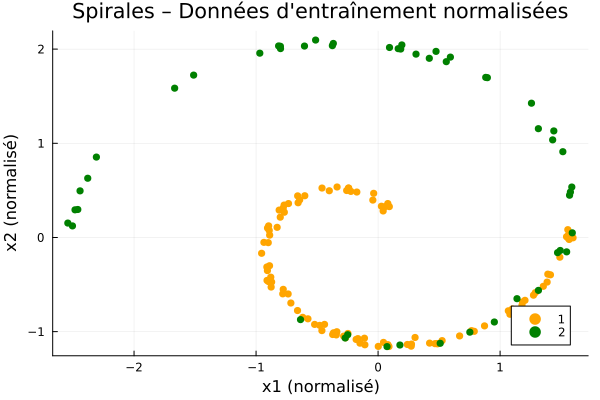

In [12]:
using Plots; gr()

# Vraies étiquettes (1 ou 2)
true_labels_train = argmax.(eachrow(Y_train))

# Tracé des points d'entraînement normalisés
scatter(X_train_norm[:,1], X_train_norm[:,2],
        group = true_labels_train,
        marker = :circle, msw = 0,
        palette = [:orange, :green],
        title = "Spirales – Données d'entraînement normalisées",
        xlabel = "x1 (normalisé)", ylabel = "x2 (normalisé)",
        legend = :bottomright)